### Numeric Diffusion Simulation

Diffusion equation:

$$\frac{\partial u}{\partial t} = D \frac{\partial^2 u}{\partial x^2}$$

u - vector representing the quantities we are diffusing
D - physical value that represents the properties of the fluid we are simulating.
x - spatial parameter representing the system

Solving Numerically - Using Eulers Method, we have the following approximation

$$\frac{\partial}{\partial t} u(x, t) \approx \frac{u(x, t + dt) - u(x, t)}{dt}$$

Can rewrite the above equation to find $u(x, t + dt)$, given $u(x, t)$. Applying a similar trick for $\partial x$, we obtain:

$$u(x, t + dt) = u(x, t) + dt \cdot D \cdot \frac{u(x + dx, t) - 2u(x, t) + u(x - dx, t)}{dx^2}$$

Note dx represents the resolution of the images. x will be represented using an array. For a 2D diffusion equation, add an additional spacial parameter y (below).

$$\frac{\partial}{\partial t} u(x, y, t) = D \cdot \left( \frac{\partial^2}{\partial x^2} u(x, y, t) + \frac{\partial^2}{\partial y^2} u(x, y, t) \right)$$

A similar solution follows, by applying the Euler method to both x and y

$$u(x, y, t + dt) = u(x, y, t) + dt \cdot D \cdot \left( \frac{u(x + dx, y, t) - 2u(x, y, t) + u(x - dx, y, t)}{dx^2} + \frac{u(x, y + dy, t) - 2u(x, y, t) + u(x, y - dy, t)}{dy^2} \right)$$




In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

def laplacian(u):
    lap = (
        u[2:, 1:-1] +
        u[:-2, 1:-1] +
        u[1:-1, 2:] +
        u[1:-1, :-2] -
        4*u[1:-1, 1:-1]
    )
    return lap

def evolve(grid, dt, D=2):
    grid[1:-1, 1:-1] += dt * D * laplacian(grid)
    return grid

def run(num_iterations, grid):
    fig, ax = plt.subplots()
    frames = []

    for i in range(num_iterations):
        grid = evolve(grid, 0.1)
        img = ax.imshow(grid, cmap='magma', vmin=0, vmax=1, animated=True)
        frames.append([img])

    ani = animation.ArtistAnimation(fig, frames, interval=50, blit=True)
    ani.save('diffusion.gif', writer='pillow', fps=120)

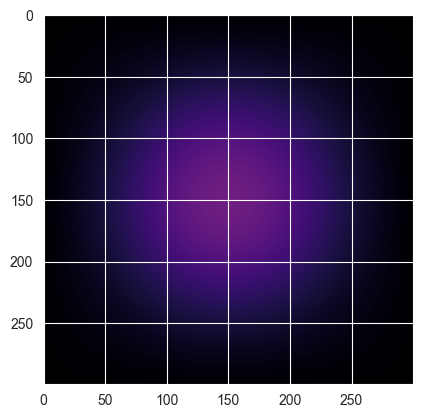

In [15]:

h, w = 100, 100
grid = np.zeros([3*h, 3*w])
grid[h:2*h, w:2*w] = 1

run(10000, grid)
